# Graph Attention Networks for Fraud-Ring Detection

CPU, ~2–4 min. **100% synthetic.** `pip install -r requirements.txt`

GAT from scratch (no PyG). Punchline: camouflaged fraud looks legit in features; the ring gives it away. MLP is the tabular baseline.


In [1]:
# Setup: pinned seed, CPU. Graph is generated below — no real accounts.
from __future__ import annotations

import random
from dataclasses import dataclass

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8.5, 4.5)

SEED = 21
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cpu")
print(f"torch {torch.__version__}  |  device: {DEVICE}")


torch 2.8.0  |  device: cpu


In [2]:
# Graph generator knobs. legit clusters exist so "dense ≠ fraud".
@dataclass
class GraphConfig:
    n_legit: int = 760
    n_rings: int = 5
    ring_lo: int = 11
    ring_hi: int = 17
    n_legit_clusters: int = 6      # dense-but-honest groups (families / payroll)
    cluster_lo: int = 8
    cluster_hi: int = 14
    n_isolated_fraud: int = 22     # loud fraud with NO ring — tabular models can catch these
    camouflage_rate: float = 0.55
    ring_p: float = 0.58
    hidden: int = 24
    heads: int = 4
    dropout: float = 0.40
    epochs: int = 160
    lr: float = 8e-3
    weight_decay: float = 1e-3


GCFG = GraphConfig()
print(GCFG)


GraphConfig(n_legit=760, n_rings=5, ring_lo=11, ring_hi=17, n_legit_clusters=6, cluster_lo=8, cluster_hi=14, n_isolated_fraud=22, camouflage_rate=0.55, ring_p=0.58, hidden=24, heads=4, dropout=0.4, epochs=160, lr=0.008, weight_decay=0.001)


## 1. Synthetic payment graph

Nodes = accounts, edges = recent payments. Planted types: loud rings, camouflaged ring members, isolated loud fraud, dense-but-honest clusters.

\[
h_i'=\sigma\Big(\sum_{j\in\mathcal{N}(i)\cup\{i\}}\alpha_{ij} W h_j\Big),\quad
\alpha_{ij}=\mathrm{softmax}_j\big(\mathrm{LeakyReLU}(a^\top[Wh_i\|Wh_j])\big)
\]


In [3]:
FEATURE_NAMES = [
    "account_age_days",
    "avg_txn_usd",
    "velocity_24h",
    "unique_devices_30d",
    "night_txn_share",
    "unique_counterparties",
    "kyc_risk_flags",
    "geo_entropy",
    "in_out_ratio",
    "new_payee_share",
]


def generate_northstar_network(cfg: GraphConfig, seed: int = SEED):
    """Undirected payment graph with planted rings, camouflage, isolated fraud, and honest clusters."""
    rng = np.random.default_rng(seed)
    ring_sizes = [int(rng.integers(cfg.ring_lo, cfg.ring_hi + 1)) for _ in range(cfg.n_rings)]
    n_ring = int(sum(ring_sizes))
    n_iso = cfg.n_isolated_fraud
    n = cfg.n_legit + n_ring + n_iso

    y = np.zeros(n, dtype=np.int64)
    ring_id = np.full(n, -1, dtype=np.int64)
    camouflaged = np.zeros(n, dtype=bool)
    isolated = np.zeros(n, dtype=bool)
    in_legit_cluster = np.zeros(n, dtype=bool)

    ring_start = cfg.n_legit
    iso_start = cfg.n_legit + n_ring
    cursor = ring_start
    for r, k in enumerate(ring_sizes):
        sl = slice(cursor, cursor + k)
        y[sl] = 1
        ring_id[sl] = r
        camouflaged[sl] = rng.random(k) < cfg.camouflage_rate
        cursor += k

    iso_idx = np.arange(iso_start, n)
    y[iso_idx] = 1
    isolated[iso_idx] = True

    X = np.zeros((n, len(FEATURE_NAMES)), dtype=np.float32)

    def fill_legit_like(idx):
        """Older accounts, low night share, few new payees."""
        idx = np.asarray(idx)
        m = len(idx)
        if m == 0:
            return
        X[idx, 0] = rng.lognormal(mean=5.9, sigma=0.55, size=m)
        X[idx, 1] = rng.lognormal(mean=3.9, sigma=0.45, size=m)
        X[idx, 2] = rng.gamma(shape=2.2, scale=1.1, size=m)
        X[idx, 3] = rng.integers(1, 4, size=m).astype(np.float32)
        X[idx, 4] = rng.beta(1.6, 6.0, size=m)
        X[idx, 5] = rng.lognormal(mean=2.4, sigma=0.4, size=m)
        X[idx, 6] = rng.binomial(2, 0.08, size=m).astype(np.float32)
        X[idx, 7] = rng.beta(2.0, 3.5, size=m)
        X[idx, 8] = rng.lognormal(mean=0.0, sigma=0.25, size=m)
        X[idx, 9] = rng.beta(1.8, 5.5, size=m)

    def fill_loud_fraud(idx):
        """Young, bursty, night-heavy — separable from tabular features alone."""
        idx = np.asarray(idx)
        m = len(idx)
        if m == 0:
            return
        X[idx, 0] = rng.lognormal(mean=3.7, sigma=0.50, size=m)
        X[idx, 1] = rng.lognormal(mean=4.6, sigma=0.70, size=m)
        X[idx, 2] = rng.gamma(shape=6.5, scale=1.4, size=m)
        X[idx, 3] = rng.integers(3, 9, size=m).astype(np.float32)
        X[idx, 4] = rng.beta(4.5, 2.0, size=m)
        X[idx, 5] = rng.lognormal(mean=1.5, sigma=0.35, size=m)
        X[idx, 6] = rng.binomial(3, 0.35, size=m).astype(np.float32)
        X[idx, 7] = rng.beta(4.0, 1.6, size=m)
        X[idx, 8] = rng.lognormal(mean=0.6, sigma=0.35, size=m)
        X[idx, 9] = rng.beta(5.0, 1.8, size=m)

    legit_idx = np.arange(cfg.n_legit)
    fill_legit_like(legit_idx)
    fill_loud_fraud(np.where(y == 1)[0])
    fill_legit_like(np.where(camouflaged)[0])  # overwrite: ring members that look legit

    adj = np.zeros((n, n), dtype=np.float32)

    # Sparse background graph among legit accounts.
    for i in legit_idx:
        deg = int(rng.integers(2, 6))
        nbrs = rng.choice(legit_idx[legit_idx != i], size=min(deg, cfg.n_legit - 1), replace=False)
        adj[i, nbrs] = 1.0
        adj[nbrs, i] = 1.0

    hubs = rng.choice(legit_idx, size=10, replace=False)
    for h in hubs:
        extra = rng.choice(legit_idx, size=int(rng.integers(16, 32)), replace=False)
        adj[h, extra] = 1.0
        adj[extra, h] = 1.0

    # Dense-but-honest communities so degree is not a fraud feature.
    pool = legit_idx.copy()
    rng.shuffle(pool)
    pcur = 0
    for _ in range(cfg.n_legit_clusters):
        k = int(rng.integers(cfg.cluster_lo, cfg.cluster_hi + 1))
        members = pool[pcur : pcur + k]
        pcur += k
        in_legit_cluster[members] = True
        for a in range(len(members)):
            for b in range(a + 1, len(members)):
                if rng.random() < 0.70:
                    adj[members[a], members[b]] = 1.0
                    adj[members[b], members[a]] = 1.0

    # Fraud rings: moderately dense clique + mule edges into legit.
    cursor = ring_start
    for r, k in enumerate(ring_sizes):
        members = np.arange(cursor, cursor + k)
        for a in range(k):
            for b in range(a + 1, k):
                if rng.random() < cfg.ring_p:
                    adj[members[a], members[b]] = 1.0
                    adj[members[b], members[a]] = 1.0
            n_mules = int(rng.integers(1, 3))
            mules = rng.choice(legit_idx, size=n_mules, replace=False)
            adj[members[a], mules] = 1.0
            adj[mules, members[a]] = 1.0
        cursor += k

    # Isolated loud fraud: a few random counterparties, no clique.
    for i in iso_idx:
        nbrs = rng.choice(legit_idx, size=int(rng.integers(2, 5)), replace=False)
        adj[i, nbrs] = 1.0
        adj[nbrs, i] = 1.0

    np.fill_diagonal(adj, 1.0)  # self-loops: a node always attends to itself
    return X, y, adj, ring_id, camouflaged, isolated, in_legit_cluster, ring_sizes


X_np, y_np, adj_np, ring_id, camouflaged, isolated, in_legit_cluster, ring_sizes = generate_northstar_network(GCFG)
n_nodes = len(y_np)
print(
    f"nodes={n_nodes:,}  edges={int((adj_np.sum() - n_nodes) / 2):,}  "
    f"fraud={y_np.mean():.1%}  rings={ring_sizes}"
)
print(
    f"camouflaged={int(camouflaged.sum())}  isolated_loud={int(isolated.sum())}  "
    f"legit_cluster_members={int(in_legit_cluster.sum())}"
)


nodes=853  edges=3,609  fraud=10.9%  rings=[13, 16, 13, 15, 14]
camouflaged=39  isolated_loud=22  legit_cluster_members=77


,degree,velocity_24h,night_txn_share,new_payee_share,account_age_days
kind,,,,,
camouflaged,9.0,2.25,0.15,0.24,385.660004
isolated_loud,3.0,10.95,0.72,0.80,44.279999
legit,7.0,2.11,0.17,0.24,376.399994
legit_cluster,15.0,2.60,0.21,0.23,370.489990
loud_ring,9.0,9.07,0.70,0.76,43.430000


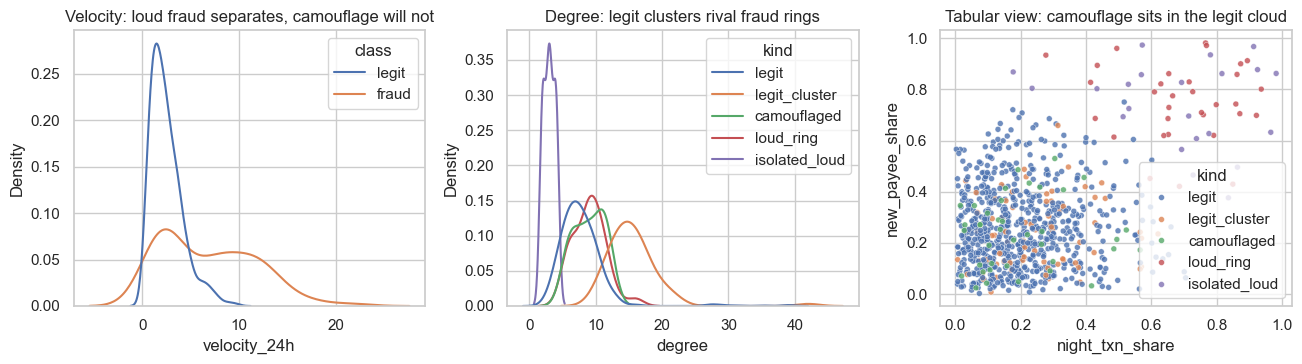

In [4]:
# Check the planted structure: camouflage should sit in the legit feature cloud; rings and payroll clusters both look dense.
kind = np.full(n_nodes, "legit", dtype=object)
kind[(y_np == 1) & ~camouflaged & ~isolated] = "loud_ring"
kind[camouflaged] = "camouflaged"
kind[isolated] = "isolated_loud"
kind[in_legit_cluster] = "legit_cluster"

degrees = adj_np.sum(1) - 1
summary = pd.DataFrame(
    {
        "kind": kind,
        "class": np.where(y_np == 1, "fraud", "legit"),
        "degree": degrees,
        "velocity_24h": X_np[:, 2],
        "night_txn_share": X_np[:, 4],
        "new_payee_share": X_np[:, 9],
        "account_age_days": X_np[:, 0],
    }
)
display(summary.groupby("kind")[["degree", "velocity_24h", "night_txn_share", "new_payee_share", "account_age_days"]]
        .median()
        .round(2))

fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.8))
sns.kdeplot(data=summary, x="velocity_24h", hue="class", ax=axes[0], common_norm=False)
axes[0].set_title("Velocity: loud fraud separates, camouflage will not")
sns.kdeplot(data=summary, x="degree", hue="kind", ax=axes[1], common_norm=False)
axes[1].set_title("Degree: legit clusters rival fraud rings")
sns.scatterplot(
    data=summary,
    x="night_txn_share",
    y="new_payee_share",
    hue="kind",
    ax=axes[2],
    s=18,
    alpha=0.8,
)
axes[2].set_title("Tabular view: camouflage sits in the legit cloud")
fig.tight_layout()
plt.show()


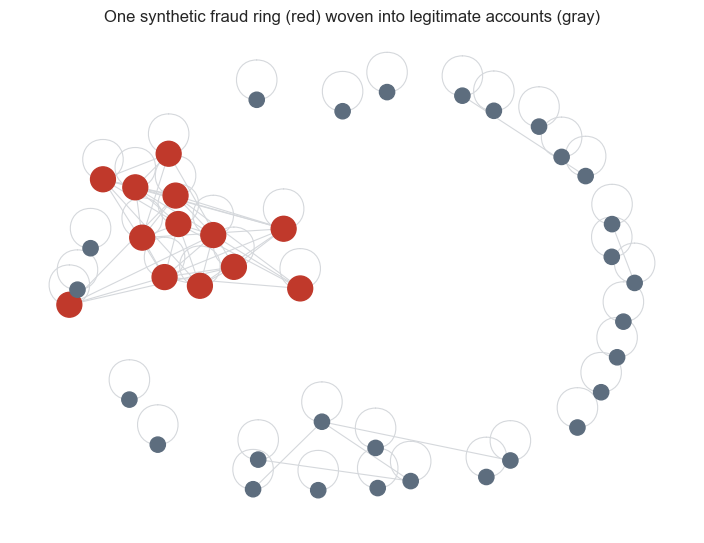

In [5]:
# One planted ring (red) plus a random legit sample (gray).
ring0 = np.where(ring_id == 0)[0]
rng = np.random.default_rng(SEED)
nearby = rng.choice(np.where(y_np == 0)[0], size=28, replace=False)
keep = np.concatenate([ring0, nearby])
sub = adj_np[np.ix_(keep, keep)]
g = nx.from_numpy_array(sub)
mapping = {i: int(keep[i]) for i in range(len(keep))}
g = nx.relabel_nodes(g, mapping)
pos = nx.spring_layout(g, seed=SEED, k=0.9)
colors = ["#c0392b" if y_np[n] == 1 else "#5d6d7e" for n in g.nodes]
sizes = [320 if y_np[n] == 1 else 120 for n in g.nodes]
fig, ax = plt.subplots(figsize=(7.2, 5.6))
nx.draw_networkx(g, pos=pos, ax=ax, node_color=colors, node_size=sizes, with_labels=False, edge_color="#d5d8dc", width=0.8)
ax.set_title("One synthetic fraud ring (red) woven into legitimate accounts (gray)")
ax.axis("off")
fig.tight_layout()
plt.show()


## 2. Transductive split

Full graph is observed; labels are hidden on val/test. Stratify so camouflage and isolated fraud appear in every split. Scale from train nodes only.


In [6]:
def stratified_masks(y, camo, iso, seed=SEED, train=0.55, val=0.20):
    """Strata: legit / loud-ring / camouflaged / isolated."""
    rng = np.random.default_rng(seed)
    n = len(y)
    tr = np.zeros(n, dtype=bool)
    va = np.zeros(n, dtype=bool)
    te = np.zeros(n, dtype=bool)
    # strata: legit, loud-ring, camouflaged, isolated
    strata = np.zeros(n, dtype=np.int64)
    strata[(y == 1) & ~camo & ~iso] = 1
    strata[camo] = 2
    strata[iso] = 3
    for s in (0, 1, 2, 3):
        idx = np.where(strata == s)[0]
        rng.shuffle(idx)
        n_tr = int(round(train * len(idx)))
        n_va = int(round(val * len(idx)))
        tr[idx[:n_tr]] = True
        va[idx[n_tr : n_tr + n_va]] = True
        te[idx[n_tr + n_va :]] = True
    return tr, va, te


train_mask, val_mask, test_mask = stratified_masks(y_np, camouflaged, isolated)
print(
    "label rate  "
    f"train={y_np[train_mask].mean():.1%}  val={y_np[val_mask].mean():.1%}  test={y_np[test_mask].mean():.1%}"
)
print(
    "test slices  camouflaged=",
    int((camouflaged & test_mask).sum()),
    " isolated=",
    int((isolated & test_mask).sum()),
    " loud-ring=",
    int(((y_np == 1) & ~camouflaged & ~isolated & test_mask).sum()),
)

# Standardize features from TRAIN nodes only
mu = X_np[train_mask].mean(0, keepdims=True)
sd = X_np[train_mask].std(0, keepdims=True)
sd = np.where(sd < 1e-6, 1.0, sd)
X_std = (X_np - mu) / sd

X = torch.from_numpy(X_std).to(DEVICE)
y = torch.from_numpy(y_np).to(DEVICE)
adj = torch.from_numpy(adj_np).to(DEVICE)
train_m = torch.from_numpy(train_mask)
val_m = torch.from_numpy(val_mask)
test_m = torch.from_numpy(test_mask)


label rate  train=10.9%  val=10.6%  test=11.2%
test slices  camouflaged= 10  isolated= 6  loud-ring= 8


## 3. GAT

Veličković 2018, dense \(N\times N\) attention. Layer 1: 4 heads, concat. Layer 2: 1 head, then a linear classifier. MLP uses the same node features and ignores `adj`.


In [7]:
class GATLayer(nn.Module):
    """Additive GAT. alpha[i,j] = attention from j → i (softmax over neighbors j)."""
    def __init__(self, in_dim, out_dim, heads=4, dropout=0.3, concat=True, leaky=0.2):
        super().__init__()
        self.heads = heads
        self.out_dim = out_dim
        self.concat = concat
        self.W = nn.Linear(in_dim, heads * out_dim, bias=False)
        self.a_src = nn.Parameter(torch.empty(heads, out_dim))
        self.a_dst = nn.Parameter(torch.empty(heads, out_dim))
        self.leaky = nn.LeakyReLU(leaky)
        self.attn_drop = nn.Dropout(dropout)
        self.feat_drop = nn.Dropout(dropout)
        self.last_alpha = None
        nn.init.xavier_uniform_(self.W.weight)
        nn.init.xavier_uniform_(self.a_src)
        nn.init.xavier_uniform_(self.a_dst)

    def forward(self, x, adj):
        x = self.feat_drop(x)
        N = x.size(0)
        h = self.W(x).view(N, self.heads, self.out_dim)          # (N, H, D)
        e_src = (h * self.a_src).sum(-1)                         # (N, H)
        e_dst = (h * self.a_dst).sum(-1)
        e = self.leaky(e_src.unsqueeze(1) + e_dst.unsqueeze(0))  # (N, N, H)
        e = e.masked_fill(adj.unsqueeze(-1) == 0, float("-inf"))
        alpha = torch.softmax(e, dim=1)
        self.last_alpha = alpha.detach()
        alpha = self.attn_drop(alpha)
        out = torch.einsum("ijh,jhd->ihd", alpha, h)
        if self.concat:
            return out.reshape(N, self.heads * self.out_dim)
        return out.mean(1)


class GAT(nn.Module):
    """Two GAT layers + linear head."""
    def __init__(self, in_dim, hidden, heads, dropout, n_classes=2):
        super().__init__()
        self.gat1 = GATLayer(in_dim, hidden, heads=heads, dropout=dropout, concat=True)
        self.gat2 = GATLayer(hidden * heads, hidden, heads=1, dropout=dropout, concat=False)
        self.cls = nn.Linear(hidden, n_classes)

    def forward(self, x, adj, return_hidden=False):
        h = F.elu(self.gat1(x, adj))
        h = self.gat2(h, adj)
        logits = self.cls(h)
        if return_hidden:
            return logits, h
        return logits


class MLPBaseline(nn.Module):
    """Same depth-ish MLP; `adj` is ignored on purpose."""
    def __init__(self, in_dim, hidden, dropout, n_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden * 4),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden * 4, hidden),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, x, adj=None, return_hidden=False):
        h = self.net[:-1](x)
        logits = self.net[-1](h)
        if return_hidden:
            return logits, h
        return logits


n_pos = float((y[train_m] == 1).sum())
n_neg = float((y[train_m] == 0).sum())
# Sqrt inverse-frequency: boost recall without predicting everyone as fraud.
class_w = torch.tensor([1.0, (n_neg / max(n_pos, 1.0)) ** 0.5], dtype=torch.float32)
print("class weights (legit, fraud):", class_w.tolist())

gat = GAT(X.size(1), GCFG.hidden, GCFG.heads, GCFG.dropout).to(DEVICE)
mlp = MLPBaseline(X.size(1), GCFG.hidden, GCFG.dropout).to(DEVICE)
print("GAT params", sum(p.numel() for p in gat.parameters()))
print("MLP params", sum(p.numel() for p in mlp.parameters()))


class weights (legit, fraud): [1.0, 2.8628792762756348]
GAT params 3554
MLP params 3434


## 4. Training

Class-weighted CE. Early-stop on val PR-AUC (accuracy is the majority-class trap). Loss is computed on the train mask only; message passing still uses the full graph.


In [8]:
@torch.no_grad()
def pr_auc(model, mask):
    model.eval()
    logits = model(X, adj)
    prob = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
    yt = y.cpu().numpy()
    m = mask.cpu().numpy()
    if yt[m].sum() == 0:
        return 0.0, prob
    return average_precision_score(yt[m], prob[m]), prob


def fit_node_model(model, name, epochs=GCFG.epochs, lr=GCFG.lr):
    """Transductive: full graph forward, CE only on train_mask."""
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=GCFG.weight_decay)
    crit = nn.CrossEntropyLoss(weight=class_w)
    hist = {"loss": [], "val_ap": []}
    best_ap, best_state, stale = -1.0, None, 0
    for epoch in range(1, epochs + 1):
        model.train()
        opt.zero_grad(set_to_none=True)
        logits = model(X, adj)
        loss = crit(logits[train_m], y[train_m])
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        opt.step()
        ap, _ = pr_auc(model, val_m)
        hist["loss"].append(float(loss.item()))
        hist["val_ap"].append(ap)
        star = ""
        if ap > best_ap + 1e-4:
            best_ap = ap
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            stale = 0
            star = "  * best"
        else:
            stale += 1
        if epoch == 1 or epoch % 20 == 0 or star and epoch <= 10:
            print(f"{name:5s} epoch {epoch:03d}  loss {loss.item():.4f}  val PR-AUC {ap:.3f}{star}")
        if stale >= 25 and epoch > 40:
            print(f"{name:5s} early stop at epoch {epoch}")
            break
    model.load_state_dict(best_state)
    return hist


print("=== GAT ===")
hist_gat = fit_node_model(gat, "GAT")
print("\n=== MLP (features only, ignores the graph) ===")
hist_mlp = fit_node_model(mlp, "MLP", lr=3e-3)


=== GAT ===


GAT   epoch 001  loss 0.7767  val PR-AUC 0.975  * best
GAT   epoch 002  loss 0.6298  val PR-AUC 0.992  * best
GAT   epoch 004  loss 0.4621  val PR-AUC 0.997  * best
GAT   epoch 006  loss 0.3262  val PR-AUC 1.000  * best


GAT   epoch 020  loss 0.1220  val PR-AUC 1.000


GAT   epoch 040  loss 0.0749  val PR-AUC 1.000
GAT   early stop at epoch 41

=== MLP (features only, ignores the graph) ===
MLP   epoch 001  loss 0.7001  val PR-AUC 0.356  * best
MLP   epoch 002  loss 0.6088  val PR-AUC 0.546  * best
MLP   epoch 003  loss 0.5697  val PR-AUC 0.644  * best
MLP   epoch 004  loss 0.5283  val PR-AUC 0.649  * best
MLP   epoch 005  loss 0.4890  val PR-AUC 0.652  * best
MLP   epoch 006  loss 0.4608  val PR-AUC 0.654  * best
MLP   epoch 007  loss 0.4367  val PR-AUC 0.655  * best
MLP   epoch 010  loss 0.4145  val PR-AUC 0.655  * best
MLP   epoch 020  loss 0.3710  val PR-AUC 0.642
MLP   epoch 040  loss 0.3247  val PR-AUC 0.631
MLP   early stop at epoch 41


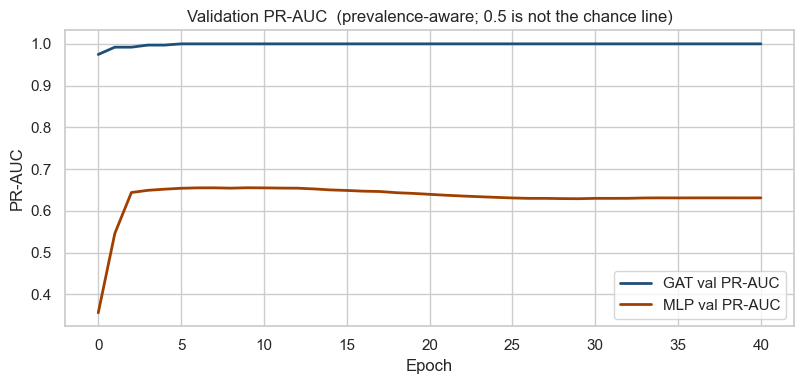

In [9]:
# Val PR-AUC over epochs. Chance is prevalence (~0.11), not 0.5.
fig, ax = plt.subplots(figsize=(8.2, 4.0))
ax.plot(hist_gat["val_ap"], color="#1f4e79", lw=2, label="GAT val PR-AUC")
ax.plot(hist_mlp["val_ap"], color="#a04000", lw=2, label="MLP val PR-AUC")
ax.set_xlabel("Epoch")
ax.set_ylabel("PR-AUC")
ax.set_title("Validation PR-AUC  (prevalence-aware; 0.5 is not the chance line)")
ax.legend()
fig.tight_layout()
plt.show()


## 5. Test slices

Headline: PR-AUC. Decision: F1 threshold tuned on val. The tell: camouflaged recall (GAT should win) vs isolated recall (both can win).



==== GAT ====
val-tuned threshold=0.614 (val F1=1.000)
test PR-AUC=0.995  ROC-AUC=0.999  F1=0.958
recall  loud-ring=1.000  camouflaged=1.000  isolated=0.833  |  legit-cluster false-positive rate=0.000
              precision    recall  f1-score   support

       legit      0.995     0.995     0.995       190
       fraud      0.958     0.958     0.958        24

    accuracy                          0.991       214
   macro avg      0.977     0.977     0.977       214
weighted avg      0.991     0.991     0.991       214


==== MLP ====
val-tuned threshold=0.912 (val F1=0.714)
test PR-AUC=0.695  ROC-AUC=0.814  F1=0.703
recall  loud-ring=1.000  camouflaged=0.000  isolated=0.833  |  legit-cluster false-positive rate=0.000
              precision    recall  f1-score   support

       legit      0.945     1.000     0.972       190
       fraud      1.000     0.542     0.703        24

    accuracy                          0.949       214
   macro avg      0.973     0.771     0.837       2

,model,pr_auc,roc_auc,f1,threshold,loud_ring_recall,camo_recall,isolated_recall,cluster_fp
0,GAT,0.995,0.999,0.958,0.614,1.0,1.0,0.833,0.0
1,MLP,0.695,0.814,0.703,0.912,1.0,0.0,0.833,0.0


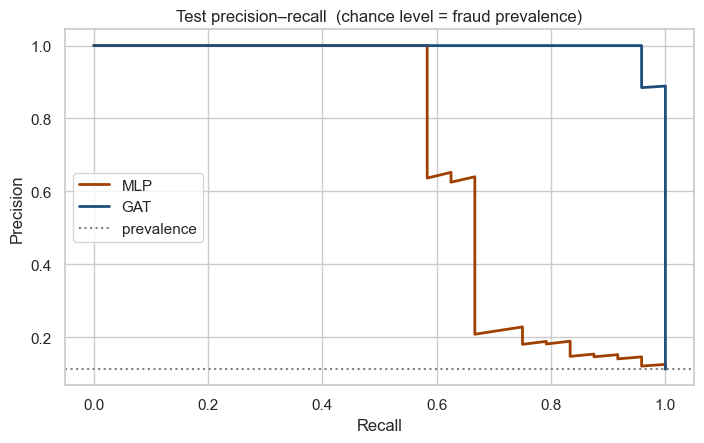

In [10]:
def best_f1_threshold(y_true, prob):
    """Pick a threshold on val; do not use softmax argmax at 0.5."""
    precision, recall, thresh = precision_recall_curve(y_true, prob)
    f1 = 2 * precision * recall / (precision + recall + 1e-12)
    # precision_recall_curve returns one extra score with no matching threshold
    i = int(np.nanargmax(f1[:-1])) if len(thresh) else 0
    return float(thresh[i]), float(f1[i])


def report(name, model):
    """Val-tuned F1 threshold, then test PR-AUC + slice recall."""
    model.eval()
    with torch.no_grad():
        logits = model(X, adj)
        prob = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
    yt = y_np
    thr, val_f1 = best_f1_threshold(yt[val_mask], prob[val_mask])
    pred = (prob >= thr).astype(np.int64)
    m = test_mask
    ap = average_precision_score(yt[m], prob[m])
    roc = roc_auc_score(yt[m], prob[m])
    f1 = f1_score(yt[m], pred[m])

    def slice_recall(mask):
        return float(pred[mask].mean()) if mask.any() else float("nan")

    camo_r = slice_recall(camouflaged & m)
    iso_r = slice_recall(isolated & m)
    ring_r = slice_recall((y_np == 1) & ~camouflaged & ~isolated & m)
    cluster_fp = float(pred[in_legit_cluster & m].mean()) if (in_legit_cluster & m).any() else float("nan")

    print(f"\n==== {name} ====")
    print(f"val-tuned threshold={thr:.3f} (val F1={val_f1:.3f})")
    print(f"test PR-AUC={ap:.3f}  ROC-AUC={roc:.3f}  F1={f1:.3f}")
    print(
        f"recall  loud-ring={ring_r:.3f}  camouflaged={camo_r:.3f}  isolated={iso_r:.3f}  "
        f"|  legit-cluster false-positive rate={cluster_fp:.3f}"
    )
    print(classification_report(yt[m], pred[m], target_names=["legit", "fraud"], digits=3))
    return dict(
        model=name,
        pr_auc=ap,
        roc_auc=roc,
        f1=f1,
        threshold=thr,
        loud_ring_recall=ring_r,
        camo_recall=camo_r,
        isolated_recall=iso_r,
        cluster_fp=cluster_fp,
        prob=prob,
        pred=pred,
    )


res_gat = report("GAT", gat)
res_mlp = report("MLP", mlp)
display(pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ("prob", "pred")} for r in (res_gat, res_mlp)]
).round(3))

fig, ax = plt.subplots(figsize=(7.2, 4.6))
for res, color in ((res_mlp, "#a04000"), (res_gat, "#1f4e79")):
    p, r, _ = precision_recall_curve(y_np[test_mask], res["prob"][test_mask])
    ax.plot(r, p, color=color, lw=2, label=res["model"])
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Test precision–recall  (chance level = fraud prevalence)")
ax.axhline(y_np[test_mask].mean(), color="gray", ls=":", label="prevalence")
ax.legend()
fig.tight_layout()
plt.show()


## 6. Did it use the ring?

GAT embeddings should pull camouflaged nodes toward the ring. Attention on a camouflaged node should put mass on ring neighbors.


/Users/lmuwayi/Documents/Hackathon Event/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/lmuwayi/Documents/Hackathon Event/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/lmuwayi/Documents/Hackathon Event/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/lmuwayi/Documents/Hackathon Event/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/lmuwayi/Documents/Hackathon Event/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/lmuwayi/Documents/Hackathon Event/.venv/lib/python3.9/site-packag

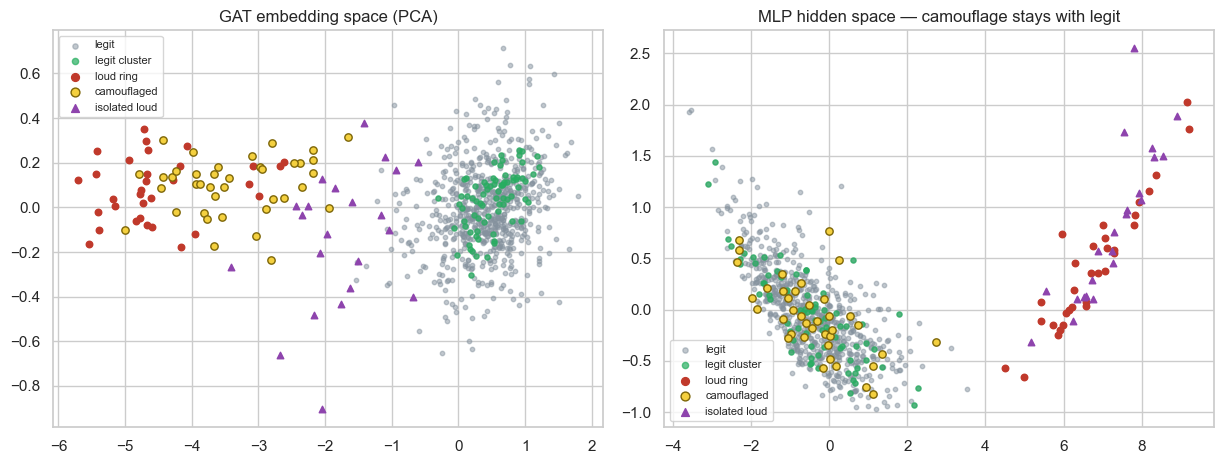

In [11]:
gat.eval()
with torch.no_grad():
    _, hidden = gat(X, adj, return_hidden=True)
# alpha[i, j] = last-layer attention from source j to node i (softmax over neighbors j)
alpha = gat.gat2.last_alpha[:, :, 0].cpu().numpy()

xy = PCA(n_components=2, random_state=SEED).fit_transform(hidden.cpu().numpy())
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.8))

def scatter_kinds(ax, xy):
    ax.scatter(xy[y_np == 0, 0], xy[y_np == 0, 1], s=10, c="#85929e", alpha=0.5, label="legit")
    ax.scatter(xy[in_legit_cluster, 0], xy[in_legit_cluster, 1], s=14, c="#27ae60", alpha=0.7, label="legit cluster")
    ax.scatter(xy[(y_np == 1) & ~camouflaged & ~isolated, 0], xy[(y_np == 1) & ~camouflaged & ~isolated, 1],
               s=22, c="#c0392b", label="loud ring")
    ax.scatter(xy[camouflaged, 0], xy[camouflaged, 1], s=28, c="#f4d03f", edgecolors="#7d6608", label="camouflaged")
    ax.scatter(xy[isolated, 0], xy[isolated, 1], s=22, c="#8e44ad", marker="^", label="isolated loud")
    ax.legend(markerscale=1.2, fontsize=8)

scatter_kinds(axes[0], xy)
axes[0].set_title("GAT embedding space (PCA)")

_, h_mlp = mlp(X, adj, return_hidden=True)
xy2 = PCA(n_components=2, random_state=SEED).fit_transform(h_mlp.detach().cpu().numpy())
scatter_kinds(axes[1], xy2)
axes[1].set_title("MLP hidden space — camouflage stays with legit")
fig.tight_layout()
plt.show()


In [12]:
# Case study: one camouflaged node in ring 0. Rank neighbors by last-layer attention.
candidates = np.where((ring_id == 0) & camouflaged)[0]
if len(candidates) == 0:
    candidates = np.where(ring_id == 0)[0]
focus = int(candidates[0])
ring_members = np.where(ring_id == 0)[0]

# alpha[i, j] = attention FROM j TO i  (softmax over j)
attn_to_focus = alpha[focus]  # weights over sources j for node `focus`
top = np.argsort(attn_to_focus)[::-1][:12]

rows = []
for j in top:
    rows.append(
        {
            "neighbor": int(j),
            "attn": float(attn_to_focus[j]),
            "is_self": j == focus,
            "in_same_ring": j in set(ring_members.tolist()),
            "label": "fraud" if y_np[j] == 1 else "legit",
            "camouflaged": bool(camouflaged[j]),
        }
    )
attn_tbl = pd.DataFrame(rows)
display(attn_tbl.round(4))

share_on_ring = attn_to_focus[ring_members].sum()
print(f"node {focus}: {share_on_ring:.1%} of last-layer attention is on its own ring (incl. self).")


,neighbor,attn,is_self,in_same_ring,label,camouflaged
0,509,0.1884,False,False,legit,False
1,338,0.1670,False,False,legit,False
2,768,0.1424,False,True,fraud,False
3,760,0.1292,True,True,fraud,True
4,770,0.1251,False,True,fraud,True
5,769,0.1251,False,True,fraud,False
6,771,0.1229,False,True,fraud,False
7,273,0.0000,False,False,legit,False
8,274,0.0000,False,False,legit,False
9,291,0.0000,False,False,legit,False


node 760: 64.5% of last-layer attention is on its own ring (incl. self).


## 7. Notes

- MLP misses camouflage; GAT should not. Isolated loud fraud is the tabular-solvable slice.
- Tune threshold on val F1. Report PR-AUC and slice recall, not accuracy.
- Stretch: directed/temporal edges, sparse kernels, GraphSAGE vs GAT — still synthetic.
